# 09 — VAR (Vector Autoregression)

VAR models all variables as jointly endogenous — each variable is regressed on its own
lags and the lags of every other variable. Unlike ARIMAX (where gold/USD are exogenous
inputs), VAR treats silver, gold, USD, copper and S&P500 returns as a system and lets
the data decide how they influence each other.

Key outputs beyond forecasting:
- **Lag order selection** (AIC/BIC)
- **Granger causality tests** — formally tests whether other variables help predict silver
- **Impulse response functions** — how a shock to one variable propagates through the system
- **Walk-forward forecast** with same DA/WDA metrics as other notebooks

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.stattools import grangercausalitytests
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120

## 1. Load and aggregate to weekly

In [2]:
train = pd.read_csv('../../data/processed/train.csv', index_col=0, parse_dates=True)
val   = pd.read_csv('../../data/processed/val.csv',   index_col=0, parse_dates=True)
test  = pd.read_csv('../../data/processed/test.csv',  index_col=0, parse_dates=True)

# VAR endogenous variables — all treated symmetrically
COLS = ['silver_return', 'gold_return', 'usd_return', 'copper_return', 'sp500_return']

def to_weekly(df):
    return df[COLS].resample('B').sum().dropna()

train_w = to_weekly(train)
val_w   = to_weekly(val)
test_w  = to_weekly(test)

all_w   = pd.concat([train_w, val_w, test_w])
n_train = len(train_w) + len(val_w)

print(f'Daily obs — train+val: {n_train}, test: {len(test_w)}')
all_w.head()

Daily obs — train+val: 2085, test: 870


,silver_return,gold_return,usd_return,copper_return,sp500_return
Date,,,,,
2015-01-05,0.027890,0.014980,0.003288,-0.016159,-0.018447
2015-01-06,0.025869,0.012711,0.001312,0.003931,-0.008933
2015-01-07,-0.005617,-0.007161,0.004253,-0.002857,0.011563
2015-01-08,-0.009677,-0.001819,0.005210,0.003926,0.017730
2015-01-09,0.002138,0.006270,-0.004666,-0.005896,-0.008439


## 2. Lag order selection

Fit VAR on the training set and select lag order by AIC and BIC.
BIC penalises extra lags more heavily — usually gives a more parsimonious model.

In [3]:
model_sel = VAR(all_w.iloc[:n_train])
lag_results = model_sel.select_order(maxlags=10)
print(lag_results.summary())

best_lag_aic = lag_results.aic
best_lag_bic = lag_results.bic
print(f'\nSelected lag — AIC: {best_lag_aic},  BIC: {best_lag_bic}')
LAG = max(best_lag_bic, 1)  # use BIC; floor at 1
print(f'Using lag: {LAG}')

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -47.20      -47.18   3.177e-21      -47.19
1       -47.28     -47.19*   2.941e-21     -47.25*
2       -47.28      -47.13   2.942e-21      -47.22
3       -47.27      -47.05   2.965e-21      -47.19
4       -47.26      -46.97   2.998e-21      -47.15
5       -47.25      -46.89   3.025e-21      -47.12
6       -47.26      -46.83   2.999e-21      -47.10
7       -47.26      -46.78   2.973e-21      -47.09
8       -47.27      -46.71   2.952e-21      -47.07
9      -47.28*      -46.66  2.916e-21*      -47.06
10      -47.27      -46.58   2.959e-21      -47.02
--------------------------------------------------

Selected lag — AIC: 9,  BIC: 1
Using lag: 1


## 3. Granger causality tests

Tests whether lagged values of each variable significantly improve forecasts of silver
beyond silver's own history. A significant result (p < 0.05) means the variable
Granger-causes silver — it adds predictive information.

Note: Granger causality is about predictability, not economic causality.

In [4]:
train_data = all_w.iloc[:n_train]

print(f'Granger causality → silver_return (maxlags={LAG}):')
print('-' * 55)
for col in [c for c in COLS if c != 'silver_return']:
    # grangercausalitytests needs [target, predictor] order
    gc_data = train_data[['silver_return', col]].dropna()
    res = grangercausalitytests(gc_data, maxlag=LAG, verbose=False)
    # Use F-test p-value at the selected lag
    p = res[LAG][0]['ssr_ftest'][1]
    sig = '*' if p < 0.05 else ''
    print(f'  {col:<20}  p={p:.4f}  {sig}')
print('\n* p < 0.05 — variable Granger-causes silver')

Granger causality → silver_return (maxlags=1):
-------------------------------------------------------
  gold_return           p=0.0983  
  usd_return            p=0.0546  
  copper_return         p=0.7824  
  sp500_return          p=0.0035  *

* p < 0.05 — variable Granger-causes silver


## 4. Impulse response functions

How does a one-standard-deviation shock to each variable affect silver return over the
next 10 weeks? Shaded area = 95% confidence interval.

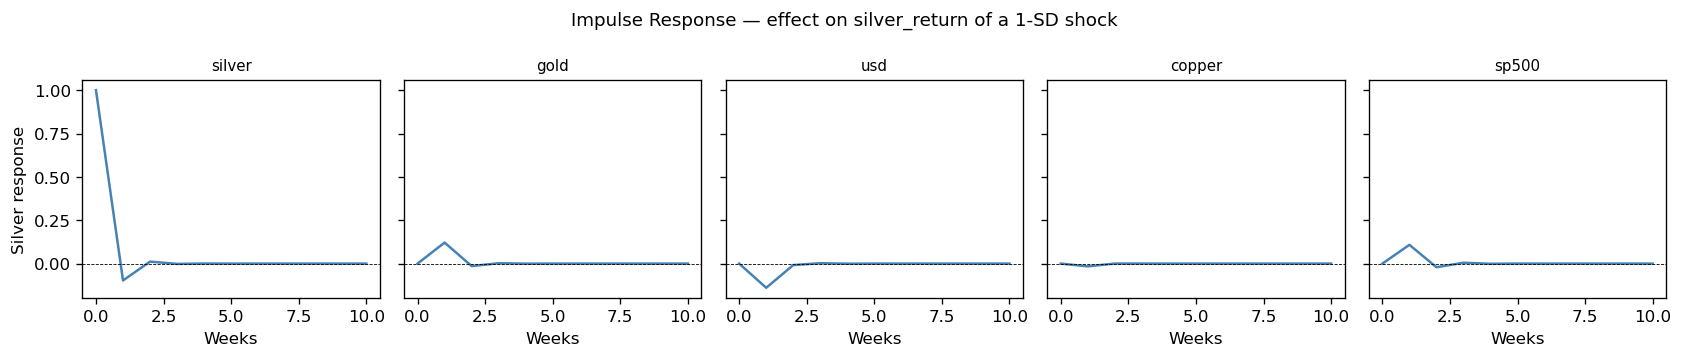

In [5]:
fitted = VAR(train_data).fit(LAG)
irf = fitted.irf(periods=10)

silver_idx = COLS.index('silver_return')
fig, axes = plt.subplots(1, len(COLS), figsize=(14, 3), sharey=True)

for j, col in enumerate(COLS):
    # Response of silver (row silver_idx) to shock in col (column j)
    response = irf.irfs[:, silver_idx, j]
    lower    = irf.cum_effect_stderr(orth=False)  # skip — use plot method instead
    axes[j].plot(response, color='steelblue', lw=1.5)
    axes[j].axhline(0, color='black', lw=0.5, ls='--')
    axes[j].set_title(col.replace('_return', ''), fontsize=9)
    axes[j].set_xlabel('Weeks')

axes[0].set_ylabel('Silver response')
fig.suptitle('Impulse Response — effect on silver_return of a 1-SD shock', fontsize=11)
plt.tight_layout()
plt.show()

## 5. Walk-forward forecast

At each test week $t$ we refit VAR on all weeks before $t$ (expanding window) and
predict one step ahead. Only the silver equation's forecast is evaluated.

In [6]:
WINDOW = 500  # rolling window size — set to None for expanding

silver_col = COLS.index('silver_return')

def var_walk_forward(all_w, n_train, lag, window=None):
    """window=None → expanding; window=N → rolling (last N weeks)."""
    preds = np.full(len(all_w) - n_train, np.nan)
    for i, t in enumerate(range(n_train, len(all_w))):
        start   = max(0, t - window) if window else 0
        history = all_w.iloc[start:t]
        try:
            model = VAR(history).fit(lag)
            fc    = model.forecast(history.values[-lag:], steps=1)
            preds[i] = fc[0, silver_col]
        except Exception:
            pass
    return preds

print('Running VAR — expanding window...')
preds_exp = var_walk_forward(all_w, n_train, LAG, window=None)
print('Running VAR — rolling window (500 days)...')
preds_rol = var_walk_forward(all_w, n_train, LAG, window=WINDOW)
print(f'Expanding: {(~np.isnan(preds_exp)).sum()} forecasts')
print(f'Rolling:   {(~np.isnan(preds_rol)).sum()} forecasts')
preds = preds_exp  # default used downstream

Running VAR — expanding window...
Running VAR — rolling window (500 days)...
Expanding: 870 forecasts
Rolling:   870 forecasts


## 6. Evaluate

In [7]:
import sys, os
sys.path.insert(0, os.path.abspath('../../src'))
from eval_utils import evaluate, period_metrics, diebold_mariano, PERIODS

y_test     = all_w['silver_return'].iloc[n_train:].values
test_index = all_w.index[n_train:]

naive_pred = all_w['silver_return'].iloc[n_train-1:-1].values

metrics = []
metrics.append(evaluate('Naive (t-1 week)',            y_test[1:], naive_pred[1:]))
metrics.append(evaluate(f'VAR({LAG}) expanding',       y_test, preds_exp))
metrics.append(evaluate(f'VAR({LAG}) rolling (500d)',  y_test, preds_rol))

metrics_df = pd.DataFrame([m for m in metrics if m is not None])
metrics_df.to_csv('../../data/processed/metrics_var_daily.csv', index=False)
metrics_df

Naive (t-1 week)                               RMSE=0.03906  MAE=0.02510  DA=0.455  WDA=0.447
VAR(1) expanding                               RMSE=0.02650  MAE=0.01626  DA=0.480  WDA=0.544
VAR(1) rolling (500d)                          RMSE=0.02669  MAE=0.01644  DA=0.507  WDA=0.542


,model,rmse,mae,dir_acc,wda
0,Naive (t-1 week),0.039063,0.025101,0.454545,0.446599
1,VAR(1) expanding,0.026504,0.016261,0.480460,0.544157
2,VAR(1) rolling (500d),0.026688,0.016438,0.506897,0.542364


## 7. Predicted vs actual

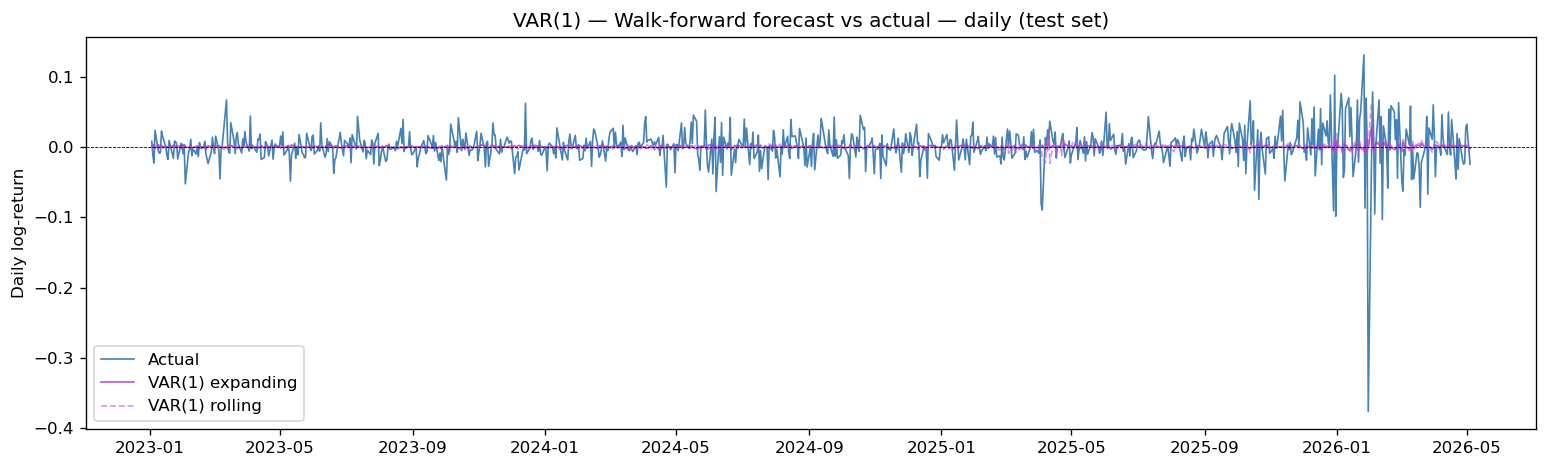

In [8]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(test_index, y_test, lw=1,   label='Actual',       color='steelblue')
ax.plot(test_index, preds_exp, lw=1, label=f'VAR({LAG}) expanding', color='darkorchid', alpha=0.8)
ax.plot(test_index, preds_rol, lw=1, label=f'VAR({LAG}) rolling',   color='mediumorchid', alpha=0.6, ls='--')
ax.axhline(0, color='black', lw=0.5, ls='--')
ax.set_title(f'VAR({LAG}) — Walk-forward forecast vs actual — daily (test set)')
ax.set_ylabel('Daily log-return')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Sentiment comparison

Adds lagged Reddit and news sentiment as endogenous variables in the VAR system.
Lag order is re-selected on each augmented dataset. Silver forecasts are compared
across three specifications: no sentiment, Reddit + News, news only (GDELT).

In [9]:
import os

sent_path = "../../data/processed/daily_sentiment.csv"
if not os.path.exists(sent_path):
    print("daily_sentiment.csv not found — run 03_sentiment.ipynb first.")
else:
    sentiment = pd.read_csv(sent_path, index_col=0, parse_dates=True)
    sent_w = sentiment[["reddit_sentiment", "news_sentiment"]].resample("B").mean()
    all_candidates = {
        "VAR expanding":      preds_exp,
        "VAR rolling (500d)": preds_rol,
    }

    def var_sentiment_run(all_w, n_train, sent_cols, label):
        sent_aligned = sent_w[sent_cols].reindex(all_w.index).ffill().fillna(0)
        all_aug = pd.concat([all_w, sent_aligned], axis=1).dropna()
        try:
            lag_sel = VAR(all_aug.iloc[:n_train]).select_order(maxlags=8)
            lag = max(lag_sel.bic, 1)
        except Exception:
            lag = LAG
        silver_col_aug = all_aug.columns.tolist().index("silver_return")
        p_exp = np.full(len(all_aug) - n_train, np.nan)
        p_rol = np.full(len(all_aug) - n_train, np.nan)
        for i, t in enumerate(range(n_train, len(all_aug))):
            for window, out in [(None, p_exp), (100, p_rol)]:
                start   = max(0, t - window) if window else 0
                history = all_aug.iloc[start:t]
                try:
                    m  = VAR(history).fit(lag)
                    fc = m.forecast(history.values[-lag:], steps=1)
                    out[i] = fc[0, silver_col_aug]
                except Exception:
                    pass
        y_t = all_aug["silver_return"].iloc[n_train:].values
        idx = all_aug.index[n_train:]
        print("--- {} ---".format(label))
        evaluate("{} expanding".format(label),      y_t, p_exp)
        evaluate("{} rolling (500d)".format(label), y_t, p_rol)
        all_candidates["{} expanding".format(label)]      = p_exp
        all_candidates["{} rolling (500d)".format(label)] = p_rol

    print("Baseline (no sentiment):")
    evaluate("VAR expanding",      y_test, preds_exp)
    evaluate("VAR rolling (500d)", y_test, preds_rol)
    print()

    print("Running VAR + Reddit + News...")
    var_sentiment_run(all_w, n_train, ["reddit_sentiment", "news_sentiment"], "Reddit+News")
    print()

    print("Running VAR + Reddit only...")
    var_sentiment_run(all_w, n_train, ["reddit_sentiment"], "Reddit only")
    print()

    print("Running VAR + News only (GDELT)...")
    var_sentiment_run(all_w, n_train, ["news_sentiment"], "News only")
    print()

Baseline (no sentiment):
VAR expanding                                  RMSE=0.02650  MAE=0.01626  DA=0.480  WDA=0.544
VAR rolling (500d)                             RMSE=0.02669  MAE=0.01644  DA=0.507  WDA=0.542

Running VAR + Reddit + News...
--- Reddit+News ---
Reddit+News expanding                          RMSE=0.02653  MAE=0.01628  DA=0.497  WDA=0.565
Reddit+News rolling (500d)                     RMSE=0.02789  MAE=0.01749  DA=0.491  WDA=0.534

Running VAR + Reddit only...
--- Reddit only ---
Reddit only expanding                          RMSE=0.02652  MAE=0.01628  DA=0.491  WDA=0.532
Reddit only rolling (500d)                     RMSE=0.02780  MAE=0.01741  DA=0.491  WDA=0.531

Running VAR + News only (GDELT)...
--- News only ---
News only expanding                            RMSE=0.02651  MAE=0.01627  DA=0.489  WDA=0.561
News only rolling (500d)                       RMSE=0.02772  MAE=0.01745  DA=0.487  WDA=0.531



## Sub-period robustness: DA and WDA by year

Breaks down the best-performing variant by calendar year to check whether
the result is stable across different market regimes.

In [10]:
best_name = max(all_candidates, key=lambda k:
    np.nansum(np.abs(y_test) * (np.sign(y_test) == np.sign(all_candidates[k]))) /
    np.nansum(np.abs(y_test)))
best_pred = all_candidates[best_name]
print("Best variant by WDA:", best_name)
res = period_metrics(y_test, best_pred, test_index, PERIODS)
display(res[["n", "DA", "WDA"]].style
        .format({"n": "{:.0f}", "DA": "{:.3f}", "WDA": "{:.3f}"})
        .background_gradient(cmap="RdYlGn", subset=["DA", "WDA"], vmin=0.4, vmax=0.7))

Best variant by DA: VAR rolling (500d)


,n,DA,WDA
Period,,,
2023 (choppy),259,0.510,0.513
2024 (bull start),262,0.469,0.460
2025 (bull run),261,0.548,0.656
2026 (YTD),88,0.489,0.518
── Full test ──,870,0.507,0.542


## Diebold-Mariano test

Tests whether sentiment variants produce statistically significant forecast improvements
over the no-sentiment baseline. H0: equal predictive accuracy (squared error loss).
p < 0.05 = significant improvement.

In [11]:
print("Diebold-Mariano tests — each variant vs no-sentiment baseline")
print("H0: equal predictive accuracy  |  * p<0.05  ** p<0.01  *** p<0.001  ns=not significant")
print("-" * 90)

baseline_key  = "VAR expanding"
baseline_pred = all_candidates[baseline_key]
for name, pred in all_candidates.items():
    if name == baseline_key:
        continue
    diebold_mariano(y_test, baseline_pred, pred, baseline_key, name)

Diebold-Mariano tests — each variant vs no-sentiment baseline
H0: equal predictive accuracy  |  * p<0.05  ** p<0.01  *** p<0.001  ns=not significant
------------------------------------------------------------------------------------------
VAR expanding                            vs VAR rolling (500d)                        DM=-1.129  p=0.259  (ns)
VAR expanding                            vs Reddit+News expanding                     DM=-1.743  p=0.081  (ns)
VAR expanding                            vs Reddit+News rolling (500d)                DM=-2.272  p=0.023  *
  -> VAR expanding is significantly more accurate
VAR expanding                            vs Reddit only expanding                     DM=-1.886  p=0.059  (ns)
VAR expanding                            vs Reddit only rolling (500d)                DM=-2.438  p=0.015  *
  -> VAR expanding is significantly more accurate
VAR expanding                            vs News only expanding                       DM=-0.255  p=0.799  (ns)


## 2026 zoom — actual vs best model

Focuses on the most recent out-of-sample period where silver has been most active.
Uses the best-performing variant selected earlier.

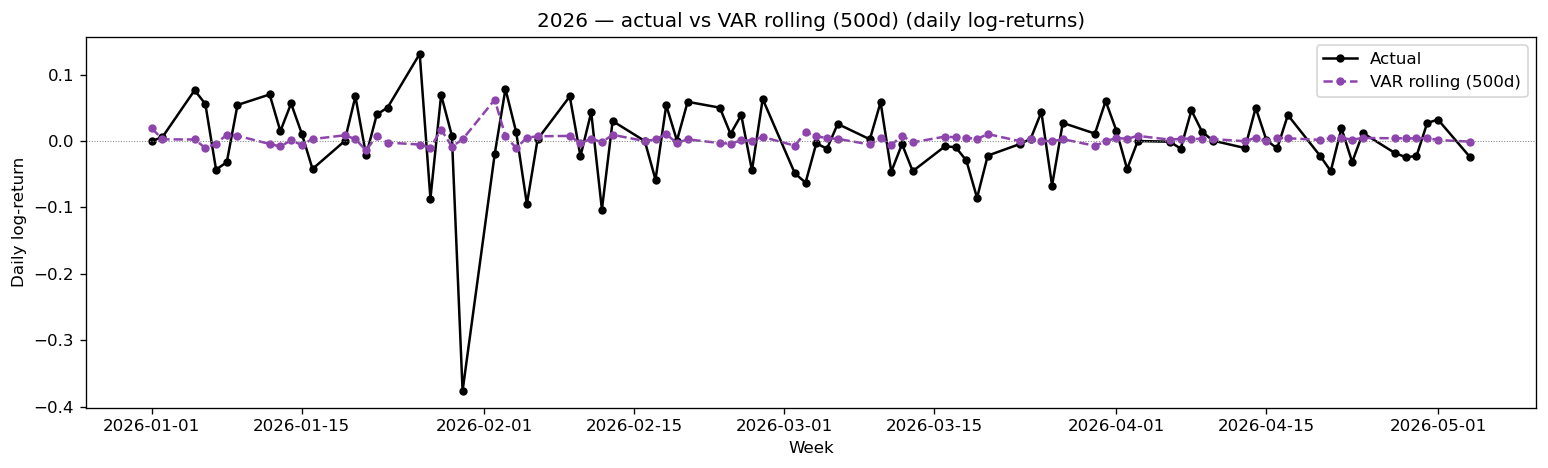

In [12]:
df26 = pd.DataFrame({"actual": y_test, "pred": best_pred}, index=test_index)
df26 = df26.loc["2026":]

if df26.empty:
    print("No 2026 data in test set yet.")
else:
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(df26.index, df26["actual"], color="black",  lw=1.5, marker="o", ms=4, label="Actual")
    ax.plot(df26.index, df26["pred"],   color="#8e44ad", lw=1.5, marker="o", ms=4,
            ls="--", label=f"{best_name}")
    ax.axhline(0, color="grey", lw=0.6, ls=":")
    ax.set_title(f"2026 — actual vs {best_name} (daily log-returns)", fontsize=12)
    ax.set_ylabel("Daily log-return")
    ax.set_xlabel("Week")
    ax.legend()
    plt.tight_layout()
    plt.show()